# Laboratoire 01 — Mesures informationnelles et indicateurs de référence

**Projet PHY-3202 — Détection entropique des pannes en cascade**
Alex Baker, superviseur : Patrick Desrosiers

---

## À quoi sert ce carnet

Le projet demande si des mesures issues de la théorie de l'information
permettent de distinguer des régimes de réseau présentant des vulnérabilités
différentes, et si elles apportent quelque chose que des indicateurs plus
simples ne donnent pas déjà.

Avant de poser cette question à des données de réseau, il faut savoir ce que
ces mesures font réellement. Une mesure appliquée à des données dont on ignore
la structure ne s'interprète pas : on ne saurait pas distinguer un résultat
d'un artefact. Ce carnet établit donc le comportement de chaque outil sur des
séries dont la structure est connue d'avance.

Aucune logique de calcul ne vit ici. Tout provient du paquet `cascade_entropy`,
couvert par la suite de tests. Le carnet explique et démontre, le paquet
calcule.

## Plan

1. Ce qu'est une entropie, et sur quoi on la calcule
2. Les séries de référence
3. Entropie de permutation
4. Entropie d'échantillon
5. Entropie multiéchelle et le croisement de Costa
6. Entropie de répartition et nombre effectif
7. Exposant de Hurst et sa distribution nulle
8. Un piège : les égalités exactes
9. Le réseau en arbre et les flux

In [56]:
import numpy as np

from cascade_entropy import figures
from cascade_entropy.entropie import (
    echantillon,
    entropie_repartition,
    granulariser,
    multiechelle,
    nombre_effectif,
    permutation,
    shannon,
)
from cascade_entropy.indicateurs import (
    distribution_nulle_hurst,
    exposant_loi_de_puissance,
    hurst,
    intervalle_nul,
    rs_par_echelle,
    survie,
)
from cascade_entropy.reseau import (
    arbre,
    degres,
    flux,
    limites_par_niveau,
    matrice_de_flux,
    taux_de_charge,
)
from cascade_entropy.synthetiques import bruit_puissance, periodique

figures.appliquer_style()

GRAINE = 20260915
N = 8192

rng = np.random.default_rng(GRAINE)

print(f"numpy {np.__version__} — graine {GRAINE} — séries de {N} points")

numpy 2.3.4 — graine 20260915 — séries de 8192 points


---
## 1. Ce qu'est une entropie, et sur quoi on la calcule

Une entropie ne se calcule jamais directement sur un réseau ni sur un signal.
Elle se calcule sur une **distribution de probabilité**. L'entropie de Shannon

$$\mathcal{H} = -\sum_k p_k \ln p_k$$

demande une liste de probabilités positives qui somment à 1, et rien d'autre.
Elle est maximale, valant $\ln K$, lorsque les $K$ possibilités sont
équiprobables, et nulle lorsqu'une seule est certaine.

La vraie question n'est donc pas « comment calculer une entropie sur un
réseau », mais **de quoi fait-on la distribution**. Trois réponses possibles,
qui donnent trois physiques différentes.

**La répartition dans l'espace, à un instant donné.** Le réseau a $N_l$ lignes,
chacune portant un flux $F_l$. On pose $p_l = |F_l| / \sum_k |F_k|$ et on
obtient une distribution légitime. L'entropie mesure alors à quel point la
puissance est répartie ou concentrée. C'est la section 6.

**La répartition dans le temps, sur une observable scalaire.** On prend une
quantité qui évolue et on construit la distribution des **motifs** qu'elle
forme : ordres relatifs pour l'entropie de permutation, répétitions pour
l'entropie d'échantillon. C'est l'objet des sections 3 à 5.

**La dépendance entre deux séries.** L'entropie de transfert demande si
connaître le passé de l'une réduit l'incertitude sur le futur de l'autre. Elle
est dirigée, donc asymétrique. Ce n'est pas l'objet de ce carnet : elle est une
extension conditionnelle du projet.

In [57]:
# Vérification élémentaire : l'entropie d'une distribution uniforme sur K
# possibilités vaut ln K, et celle d'une certitude vaut zéro.
for k in (2, 6, 45):
    print(f"uniforme sur {k:>2} : H = {shannon(np.full(k, 1/k)):.4f}   ln {k} = {np.log(k):.4f}")

certaine = np.zeros(6); certaine[2] = 1.0
print(f"certitude       : H = {shannon(certaine):.4f}")

uniforme sur  2 : H = 0.6931   ln 2 = 0.6931
uniforme sur  6 : H = 1.7918   ln 6 = 1.7918
uniforme sur 45 : H = 3.8067   ln 45 = 3.8067
certitude       : H = -0.0000


---
## 2. Les séries de référence

Quatre séries suffisent à couvrir la gamme utile. Elles sont générées par
synthèse spectrale : on tire un bruit gaussien, on met sa transformée de
Fourier à l'échelle par $f^{-\beta/2}$, et on revient dans le domaine
temporel. La densité spectrale résultante est proportionnelle à $f^{-\beta}$.

| série | $\beta$ | structure |
|---|---|---|
| périodique | — | déterministe, parfaitement prévisible |
| non corrélé | 0 | aucune mémoire d'un point au suivant |
| corrélé $1/f$ | 1 | corrélations à toutes les échelles |
| brun | 2 | corrélations très fortes |

Toutes sont centrées et normalisées à variance unitaire, de sorte que les
différences observées ne viennent jamais d'un effet d'échelle.

  périodique : moyenne +5.02e-04, écart-type 0.7072
 non corrélé : moyenne -2.26e-17, écart-type 1.0000
 corrélé 1/f : moyenne +1.39e-17, écart-type 1.0000
 brun (1/f²) : moyenne -1.11e-16, écart-type 1.0000


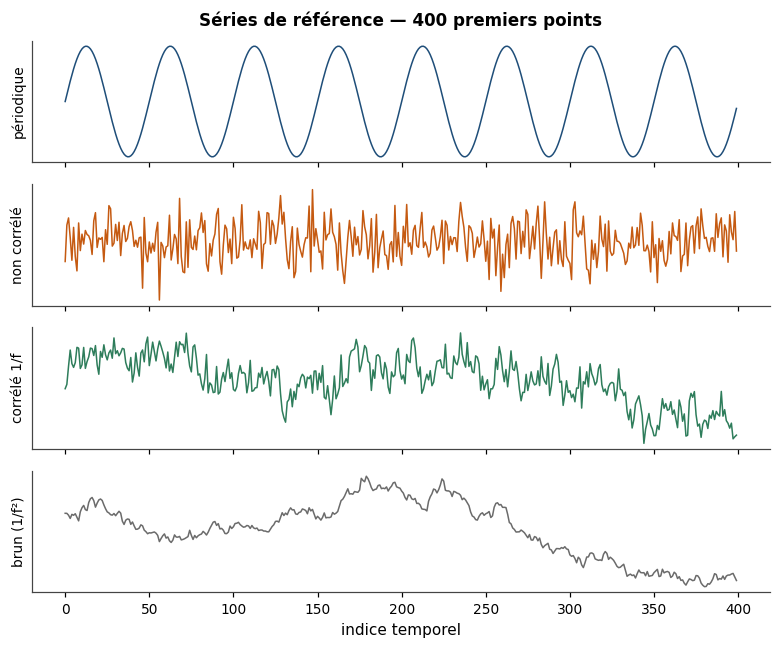

In [58]:
series = {
    "périodique": periodique(N, periode=50),
    "non corrélé": bruit_puissance(N, beta=0.0, rng=rng),
    "corrélé 1/f": bruit_puissance(N, beta=1.0, rng=rng),
    "brun (1/f²)": bruit_puissance(N, beta=2.0, rng=rng),
}

figures.galerie_series(series, n_points=400,
                       titre="Séries de référence — 400 premiers points");

for nom, serie in series.items():
    print(f"{nom:>12} : moyenne {serie.mean():+.2e}, écart-type {serie.std():.4f}")

---
## 3. Entropie de permutation

### Le principe

Bandt et Pompe proposent d'oublier complètement les amplitudes et de ne
conserver que l'**ordre relatif** des valeurs successives. On découpe la série
en fenêtres de $n$ points espacés d'un délai $\tau_{\text{PE}}$, et chaque
fenêtre est remplacée par la permutation qui trie ses valeurs.

Pour $n = 3$, il y a $3! = 6$ motifs possibles : croissant, décroissant, et
quatre formes de pic ou de creux. On compte la fréquence $p(\pi)$ de chacun sur
toute la série, puis

$$\mathcal{H}(n) = -\sum_{\pi} p(\pi) \ln p(\pi), \qquad 0 \le \mathcal{H}(n) \le \ln n!$$

La version normalisée $\mathcal{H}(n)/\ln n!$ se lit directement entre 0 et 1.

### Pourquoi cette mesure est intéressante

Elle est invariante par toute transformation monotone croissante des valeurs :
changer d'unité, passer en pour-cent, appliquer un logarithme ne change rien au
résultat. Pour des flux exprimés en unités arbitraires, c'est une propriété
commode. Elle est aussi très rapide à calculer, et robuste au bruit de mesure.

### Un exemple minuscule

Prenons une série de six points et regardons les motifs à la main.

In [59]:
exemple = np.array([4.0, 7.0, 9.0, 2.0, 5.0, 8.0])
noms_motifs = {(0,1,2): "croissant", (2,1,0): "décroissant",
               (0,2,1): "creux puis pic", (1,0,2): "pic puis creux",
               (1,2,0): "descente finale", (2,0,1): "montée finale"}

print(f"{'fenêtre':<12} {'ordre':<12} motif")
for i in range(exemple.size - 2):
    fenetre = exemple[i:i+3]
    ordre = tuple(int(k) for k in np.argsort(fenetre, kind="stable"))
    valeurs = " ".join(f"{v:.0f}" for v in fenetre)
    print(f"{valeurs:<12} {str(ordre):<12} {noms_motifs[ordre]}")

print(f"\nentropie de permutation normalisée : {permutation(exemple):.4f}")

fenêtre      ordre        motif
4 7 9        (0, 1, 2)    croissant
7 9 2        (2, 0, 1)    montée finale
9 2 5        (1, 2, 0)    descente finale
2 5 8        (0, 1, 2)    croissant

entropie de permutation normalisée : 0.5803


Quatre fenêtres, trois motifs distincts dont un répété : l'entropie est donc
non nulle mais loin du maximum. Sur une vraie série, le même comptage porte sur
des milliers de fenêtres.

### Le comportement sur les séries de référence

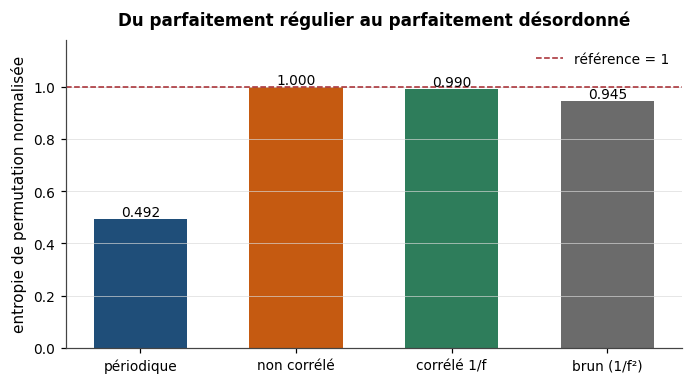

In [60]:
pe = {nom: permutation(serie) for nom, serie in series.items()}

figures.barres_comparatives(
    pe, ylabel="entropie de permutation normalisée",
    titre="Du parfaitement régulier au parfaitement désordonné", reference=1.0
);

### Lecture de la figure

Chaque barre est l'entropie de permutation normalisée d'une des quatre séries, et la ligne pointillée marque le maximum théorique, atteint lorsque les six motifs ordinaux sont équiprobables. L'axe se lit donc comme une fraction du désordre maximal possible.

**Le bruit non corrélé, à 1,000.** C'est le comportement attendu et il sert de contrôle. Chaque point est tiré indépendamment du précédent, donc aucun ordre relatif n'est privilégié : les six motifs apparaissent chacun une fois sur six. Si cette barre n'était pas au maximum, il y aurait un défaut dans le générateur ou dans la mesure.

**Le signal périodique, à 0,492.** C'est la valeur la plus instructive, et elle se prédit à la main.

La sinusoïde a une période de 50 points. Sur ces 50 fenêtres consécutives, environ 24 se trouvent dans la phase montante et donnent le motif croissant, 24 dans la phase descendante et donnent le motif décroissant. Les deux ou trois fenêtres restantes chevauchent un sommet ou un creux et produisent l'un des quatre motifs non monotones. La distribution attendue est donc approximativement

 $$p \approx \left(0{,}48,\ 0{,}48,\ 0{,}01,\ 0{,}01,\ 0{,}01,\ 0{,}01\right)$$

d'où

 $$\mathcal{H}(3) \approx 2 \times 0{,}48 \ln\frac{1}{0{,}48}
   + 4 \times 0{,}01 \ln\frac{1}{0{,}01} \approx 0{,}889 \ \text{nats}$$

soit, une fois normalisé par $\ln 6 \approx 1{,}7918$, une valeur voisine de **0,496**. La mesure en donne 0,492 : l'écart vient uniquement du fait que le nombre exact de fenêtres non monotones par période dépend de la phase d'échantillonnage.

Le point à retenir est qu'une sinusoïde ne donne pas zéro. Elle emploie essentiellement deux motifs sur six, et deux motifs équiprobables valent déjà $\ln 2 / \ln 6 \approx 0{,}387$. Une entropie de permutation nulle exigerait une série strictement monotone, qui n'emploie qu'un seul motif.

**Le bruit en $1/f$, à 0,990.** Presque au maximum, et pourtant cette série possède des corrélations à toutes les échelles de temps. C'est une limite importante de la mesure : à dimension 3 et délai 1, elle ne regarde que trois points consécutifs et ne peut donc pas voir une structure qui s'étend sur des centaines de points. La section 5 lui apportera précisément ce qui lui manque ici.

**Le bruit brun, à 0,945.** C'est le résultat contre-intuitif de la figure.
Visuellement, c'est de loin la série la plus erratique des quatre — et c'est pourtant celle qui obtient la valeur la plus basse après la sinusoïde.

La raison tient à ce que la mesure regarde. Le bruit brun a un spectre en
$1/f^2$, donc ses variations successives sont fortement corrélées : après une
montée, une nouvelle montée est plus probable qu'une descente. Les motifs monotones sont donc sur-représentés, et l'entropie baisse. L'amplitude des oscillations, qui est ce que l'œil perçoit, n'entre nulle part dans le calcul puisque seul l'ordre compte.

**La conclusion, et c'est le fil directeur du projet.** Ce qui a l'air le plus désordonné n'est pas ce qui contient le moins de structure. L'entropie de permutation classe les séries selon la prévisibilité de leur **ordre local**, pas selon leur apparence.

### L'effet du délai

Le délai $\tau_{\text{PE}}$ permet de sonder la structure à différentes échelles de temps. Sur un signal périodique, il produit un effet spectaculaire.

In [61]:
print("délai   PE du signal périodique (période = 50)")
for delai in (1, 5, 12, 25, 50):
    print(f"{delai:>5}   {permutation(series['périodique'], delai=delai):.4f}")

délai   PE du signal périodique (période = 50)
    1   0.4918
    5   0.7428
   12   0.9589
   25   0.7996
   50   0.9989


La valeur monte avec le délai, jusqu'à frôler 1 — mais attention à
l'interprétation. À délai 50, soit exactement une période, les trois points
d'une fenêtre échantillonnent la même phase et sont numériquement presque
identiques. Seules les erreurs d'arrondi décident alors de leur ordre, et la
mesure renvoie un désordre parfait là où le signal est parfaitement prévisible.

C'est un premier avertissement, développé en section 8 : dès que les valeurs
comparées sont trop proches, l'entropie de permutation ne mesure plus le signal
mais la façon dont les égalités sont départagées. Le choix du délai doit donc
être justifié, jamais laissé au hasard.

---
## 4. Entropie d'échantillon

### Le principe

Richman et Moorman posent une question différente : la série est-elle
**régulière**, au sens où des configurations passées se répètent.

On construit tous les vecteurs de $m$ points consécutifs, puis on compte les
paires de vecteurs distants de moins de $r$ au sens de la distance de
Tchebychev, c'est-à-dire dont toutes les composantes diffèrent de moins de $r$.
Soit $B$ ce nombre. On refait le compte avec des vecteurs de $m+1$ points, soit
$A$. Alors

$$\mathrm{SampEn}(m, r, N) = -\ln \frac{A}{B}$$

Le rapport $A/B$ est la probabilité conditionnelle que deux segments qui se
ressemblaient sur $m$ points se ressemblent encore au point suivant. Une série
très régulière donne un rapport proche de 1, donc une entropie proche de zéro.
Une série imprévisible donne un rapport faible, donc une entropie élevée.

### Les deux paramètres

$m$ est la longueur du motif recherché, typiquement 2. $r$ est la tolérance
d'appariement, exprimée en fraction de l'écart-type, typiquement 0,15. Les
auto-appariements sont exclus, ce qui distingue SampEn de l'entropie approchée
dont elle dérive et lui évite un biais.

La mesure vaut NaN lorsqu'aucun appariement n'est trouvé. Ce n'est pas une
entropie nulle : c'est une mesure indéfinie, et elle doit être traitée comme
telle.

  périodique : SampEn = 0.2573
 non corrélé : SampEn = 2.4610
 corrélé 1/f : SampEn = 1.8095
 brun (1/f²) : SampEn = 0.1095


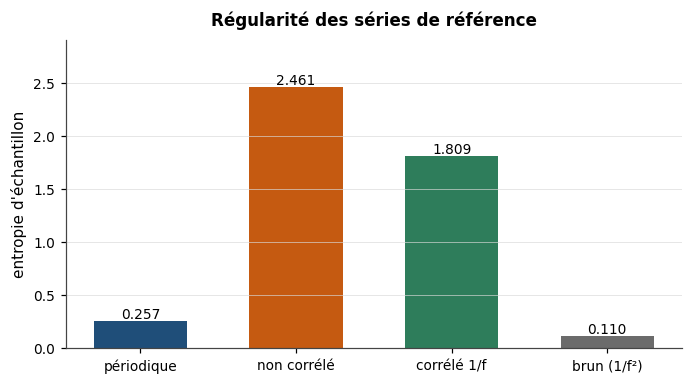

In [62]:
sampen = {nom: echantillon(serie) for nom, serie in series.items()}

for nom, valeur in sampen.items():
    print(f"{nom:>12} : SampEn = {valeur:.4f}")

figures.barres_comparatives(
    {k: v for k, v in sampen.items() if np.isfinite(v)},
    ylabel="entropie d'échantillon", titre="Régularité des séries de référence"
);

À cette échelle, le bruit non corrélé obtient la valeur la plus élevée. Pris
isolément, ce résultat suggérerait que le bruit blanc est le signal le plus
complexe qui soit — une conclusion que la section suivante va démentir.

### L'effet de la tolérance

In [63]:
print("r        SampEn du bruit non corrélé")
for r in (0.05, 0.10, 0.15, 0.25, 0.50):
    print(f"{r:.2f}     {echantillon(series['non corrélé'], r=r):.4f}")

r        SampEn du bruit non corrélé
0.05     3.4818
0.10     2.8601
0.15     2.4610
0.25     1.9650
0.50     1.2858


### Ce que la tolérance contrôle réellement

Le paramètre $r$ est le rayon d'appariement. Deux segments de $m$ points sont considérés comme semblables si **toutes** leurs composantes diffèrent de moins de $r$ — c'est la distance de Tchebychev, qui est la plus exigeante des distances usuelles puisqu'une seule composante trop écartée suffit à rejeter la paire.

Il est exprimé en fraction de l'écart-type, jamais en unité physique. Deux raisons à cela. D'abord, la mesure devient invariante par changement d'unité : multiplier la série par mille ne change rien. Ensuite, la valeur retenue garde le même sens d'une série à l'autre, ce qui rend les comparaisons possibles.

### Pourquoi la valeur mesurée décroît quand $r$ augmente

Rappelons que

$$\mathrm{SampEn} = -\ln \frac{A}{B}$$

où $B$ compte les paires de segments semblables sur $m$ points et $A$ celles qui le restent sur $m+1$ points. Les deux comptes augmentent avec $r$, mais pas à la même vitesse.

**Quand $r$ est grand**, apparier sur un point de plus ne coûte presque rien : si deux segments passent déjà le test sur $m$ points avec une tolérance large, le point suivant a toutes les chances de passer aussi. Le rapport $A/B$ tend vers 1, son logarithme vers 0, et la mesure s'effondre. À la limite, tous les segments s'apparient et la mesure ne distingue plus rien.

**Quand $r$ est petit**, chaque appariement supplémentaire devient coûteux. $A/B$ devient faible, et $-\ln(A/B)$ grand. C'est ce qu'on lit dans le tableau : la valeur passe de 1,29 à 3,48 quand $r$ descend de 0,50 à 0,05.

**Le piège du petit $r$.** Cette croissance n'est pas une meilleure sensibilité. En dessous d'un certain seuil, les appariements deviennent si rares que les comptes ne sont plus que du bruit d'échantillonnage, et la valeur obtenue varie fortement d'une réalisation à l'autre. Plus bas encore, $A$ tombe à zéro et la mesure devient **indéfinie** — elle retourne alors NaN, et non pas zéro. Une entropie nulle signifierait « parfaitement prévisible », ce qui est exactement le contraire de « je n'ai trouvé aucun appariement ».

### Le choix du projet

Les valeurs $m = 2$ et $r = 0{,}15$ sont celles de la littérature de référence. Elles ne sont pas optimales dans l'absolu : elles sont conventionnelles, ce qui est plus utile, puisque ça rend les résultats comparables aux valeurs publiées.

Ce qui compte pour l'interprétation n'est pas la valeur absolue de SampEn, qui dépend du couple $(m, r)$ retenu, mais **les écarts entre séries comparées avec les mêmes paramètres**. Le projet ne cherchera jamais à dire qu'une série a une entropie de 1,8 dans l'absolu, mais qu'elle en a plus ou moins qu'une autre, ou que sa valeur change avec le paramètre de contrôle du réseau.

### Une conséquence qui décide de la section suivante

La tolérance étant définie en fraction de l'écart-type, il faut décider **de quel écart-type** on parle dès qu'on modifie la série.

En entropie multiéchelle, la granularisation réduit la variance à chaque échelle. Si $r$ était recalculé sur la série granularisée, la tolérance rétrécirait au même rythme que le signal, et la mesure ne verrait jamais la perte d'information due au moyennage. Le résultat serait une courbe approximativement plate pour n'importe quelle série, et le croisement disparaîtrait.

C'est pourquoi la tolérance reste fixée sur l'écart-type de la série **d'origine**, pour toutes les échelles. La section 5 montre l'ampleur de cette réduction de variance, et la suite du carnet montre ce que la mesure révèle une fois ce choix fait correctement.

---
## 5. Entropie multiéchelle

### Le principe

Costa, Goldberger et Peng partent d'un constat gênant : l'entropie
d'échantillon classe le bruit blanc au-dessus de signaux physiologiques
manifestement plus structurés. Leur diagnostic est que la mesure ne regarde
qu'une seule échelle de temps.

Leur correction est la **granularisation**. Pour un facteur d'échelle $\tau$,
on remplace la série par les moyennes de ses blocs disjoints de $\tau$ points :

$$y_j^{(\tau)} = \frac{1}{\tau} \sum_{i=(j-1)\tau+1}^{j\tau} x_i$$

On calcule ensuite SampEn sur chaque série granularisée, et on trace le
résultat en fonction de $\tau$.

### Le détail qui décide de tout

La tolérance $r$ est calculée **une seule fois**, sur l'écart-type de la série
d'origine, et reste fixe pour toutes les échelles. La granularisation réduit la
variance ; si on recalculait $r$ à chaque échelle, la tolérance suivrait cette
réduction et effacerait exactement l'effet que la mesure cherche à révéler.
C'est l'erreur la plus fréquente dans les implémentations maison, et le projet
la verrouille par un test dédié.

In [64]:
print("échelle   longueur   écart-type après granularisation")
for tau in (1, 2, 5, 10, 20):
    granulee = granulariser(series["non corrélé"], tau)
    print(f"{tau:>7}   {granulee.size:>8}   {granulee.std():.4f}")

échelle   longueur   écart-type après granularisation
      1       8192   1.0000
      2       4096   0.7186
      5       1638   0.4677
     10        819   0.3404
     20        409   0.2432


L'écart-type décroît comme $1/\sqrt{\tau}$ pour un bruit non corrélé, ce qui
est le comportement attendu d'une moyenne de variables indépendantes. Pour un
signal corrélé, la décroissance est bien plus lente : c'est déjà tout le
principe de la mesure.

### Le croisement

échelle  1 : non corrélé 2.469   1/f 1.889
échelle 15 : non corrélé 1.126   1/f 1.829


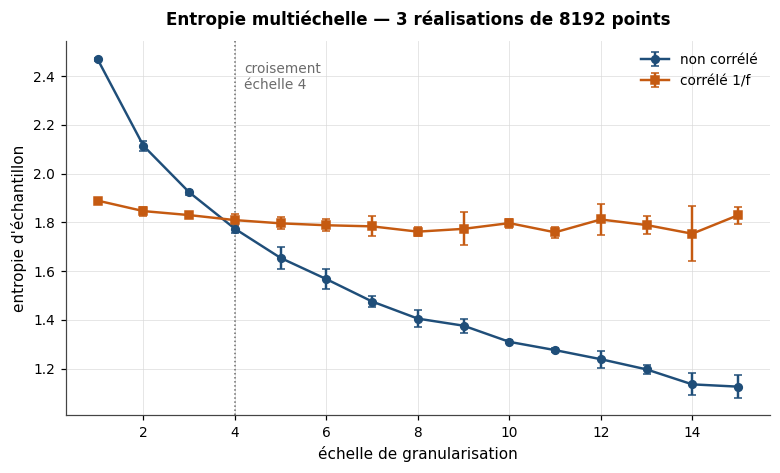

In [65]:
ECHELLES = 15
N_REALISATIONS = 3

def courbe(beta):
    """Moyenne et dispersion de MSE sur plusieurs réalisations."""
    resultats = []
    for _ in range(N_REALISATIONS):
        tau, valeurs = multiechelle(bruit_puissance(N, beta=beta, rng=rng),
                                    echelles=ECHELLES)
        resultats.append(valeurs)
    empilees = np.vstack(resultats)
    return tau, empilees.mean(axis=0), empilees.std(axis=0, ddof=1)

tau, moy_blanc, ec_blanc = courbe(0.0)
_, moy_rose, ec_rose = courbe(1.0)

figures.courbes_multiechelle(
    tau,
    {"non corrélé": moy_blanc, "corrélé 1/f": moy_rose},
    {"non corrélé": ec_blanc, "corrélé 1/f": ec_rose},
    titre=f"Entropie multiéchelle — {N_REALISATIONS} réalisations de {N} points",
);

print(f"échelle  1 : non corrélé {moy_blanc[0]:.3f}   1/f {moy_rose[0]:.3f}")
print(f"échelle {int(tau[-1]):2d} : non corrélé {moy_blanc[-1]:.3f}   1/f {moy_rose[-1]:.3f}")

**Le résultat.** À l'échelle 1, le bruit non corrélé domine. Après
granularisation, il s'effondre tandis que le bruit corrélé conserve son
entropie sur toutes les échelles. Les deux courbes se croisent.

L'interprétation est physique. Moyenner un bruit sans mémoire détruit
l'information qu'il contenait, parce qu'il n'y avait rien d'autre que du
désordre local. Moyenner un signal corrélé à longue portée ne détruit rien,
parce que la structure existe à toutes les échelles et survit au moyennage.

**Conséquence pour le projet.** Le signal le plus irrégulier de tous est celui
dont la complexité chute le plus vite avec l'échelle. Irrégularité et
complexité sont donc deux propriétés distinctes, et c'est exactement pourquoi
le sous-objectif SO3 prévoit du multiéchelle plutôt que de l'entropie brute.
Ce point n'a plus besoin d'être justifié par citation : il est reproduit ici,
et le résultat est identique entre une machine Linux et une machine Windows.

---
## 6. Entropie de répartition et nombre effectif

### Le principe

Les mesures précédentes portent sur une série temporelle. Celle-ci porte sur un
**instant**. À un moment donné, chaque ligne du réseau porte un flux $F_l$. On
pose

$$p_l = \frac{|F_l|}{\sum_k |F_k|}, \qquad
  \mathcal{H} = -\sum_l p_l \ln p_l$$

et l'exponentielle $e^{\mathcal{H}}$ donne le **nombre effectif de lignes**
portant le réseau.

### Pourquoi cette quantité est la bonne

Elle a une interprétation directe : si $K$ lignes se partagent la puissance
également, le nombre effectif vaut exactement $K$ ; si une seule porte tout, il
vaut 1. Deux réseaux transportant la même puissance totale, l'un sur cinq
lignes effectives et l'autre sur deux, n'ont pas la même fragilité — et un
seul nombre le dit, sans avoir à inspecter les lignes une par une.

Elle est aussi insensible au signe des flux, ce qui est correct puisqu'un flux
négatif indique un sens de circulation et non une charge négative. Et elle est
invariante par changement d'unité.

C'est l'observable ajoutée au sous-objectif SO2 du plan de travail.

In [66]:
cas = {
    "5 lignes à 20": np.full(5, 20.0),
    "80 puis 4×5": np.array([80.0, 5.0, 5.0, 5.0, 5.0]),
    "tout sur une": np.array([100.0, 0.0, 0.0, 0.0, 0.0]),
}

for nom, valeurs in cas.items():
    print(f"{nom:>15} : total {valeurs.sum():.0f}, "
          f"H = {entropie_repartition(valeurs):.4f}, "
          f"nombre effectif = {nombre_effectif(valeurs):.3f}")

  5 lignes à 20 : total 100, H = 1.6094, nombre effectif = 5.000
    80 puis 4×5 : total 100, H = 0.7777, nombre effectif = 2.176
   tout sur une : total 100, H = -0.0000, nombre effectif = 1.000


Les trois cas transportent exactement la même puissance totale. Le nombre
effectif passe de 5 à 2,18 puis à 1. C'est la concentration qui change, et
c'est elle qui décide de la fragilité.

---
## 7. Exposant de Hurst

### Le principe

C'est l'indicateur témoin principal du projet, puisque c'est la mesure utilisée
par Carreras et al. sur les séries de blackouts que le modèle produira.

La méthode R/S découpe la série en segments de longueur $n$. Sur chaque
segment, on forme la série des écarts cumulés à la moyenne, on prend son
étendue $R$, on divise par l'écart-type $S$ du segment, et on moyenne sur les
segments. Si

$$\langle R/S \rangle_n \sim n^{H}$$

alors $H$ est l'exposant de Hurst, obtenu comme la pente de $\log\langle R/S
\rangle$ en fonction de $\log n$.

### L'interprétation

$H = 0{,}5$ correspond à une série sans mémoire. $H > 0{,}5$ indique une
persistance : une hausse tend à être suivie d'une hausse. $H < 0{,}5$ indique
une antipersistance, où les variations tendent à s'inverser.

Important pour le projet : le Hurst mesure des **dépendances à longue portée**.
Il ne prétend pas mesurer la complexité ni la régularité. C'est précisément
pourquoi les mesures entropiques peuvent apporter une information
complémentaire, et pourquoi il faut les comparer plutôt que les opposer.

 non corrélé : H = 0.5580
 corrélé 1/f : H = 0.9356
 brun (1/f²) : H = 0.9918


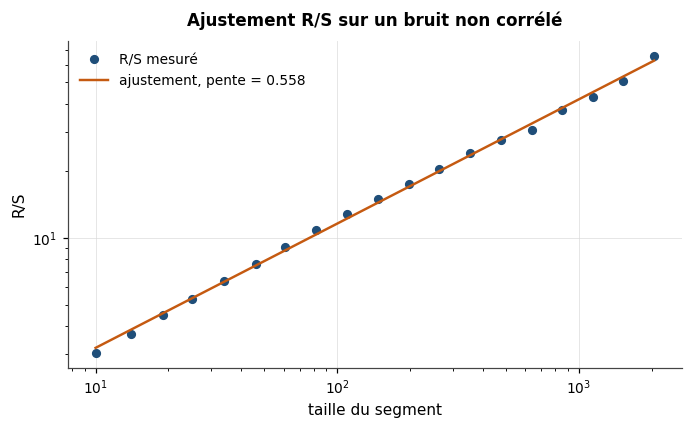

In [67]:
pente, tailles, rs, ordonnee = hurst(series["non corrélé"], retourner_ajustement=True)
figures.ajustement_rs(tailles, rs, pente, ordonnee,
                      titre="Ajustement R/S sur un bruit non corrélé");

for nom, serie in series.items():
    if nom == "périodique":
        continue          # série déterministe : l'exposant n'a pas de sens ici
    print(f"{nom:>12} : H = {hurst(serie):.4f}")

### Le biais qui change l'interprétation

L'estimateur ne retourne pas 0,5 sur un bruit dont on sait qu'il n'a aucune
corrélation. C'est le biais connu de la méthode R/S sur des séries finies :
les segments courts dominent l'ajustement et surestiment systématiquement
l'exposant.

La conséquence est méthodologique. Comparer un exposant mesuré à la valeur
théorique de 0,5 conduit à déclarer une persistance qui n'existe pas. La
référence correcte est la **distribution nulle** : l'ensemble des exposants
obtenus sur des séries non corrélées de la même longueur.

moyenne nulle      : 0.544
intervalle à 95 %  : [0.510, 0.575]
mesure sur le 1/f  : 0.936  →  hors intervalle, persistance réelle


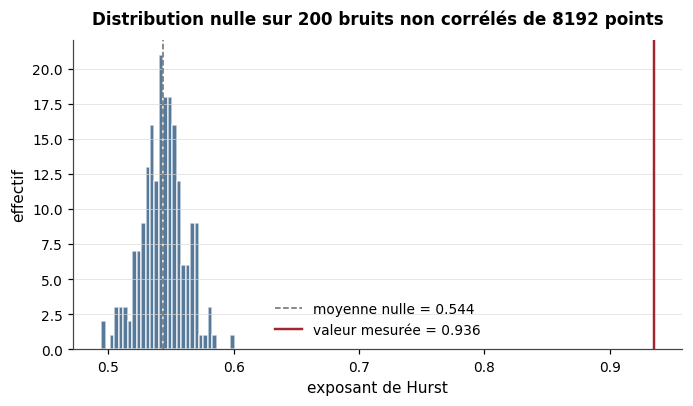

In [68]:
N_NUL = 200
nuls = distribution_nulle_hurst(N, n_tirages=N_NUL, rng=rng)
mesure_1f = hurst(series["corrélé 1/f"])

figures.distribution_nulle(
    nuls, mesure=mesure_1f, xlabel="exposant de Hurst",
    titre=f"Distribution nulle sur {N_NUL} bruits non corrélés de {N} points",
);

moyenne, bas, haut = intervalle_nul(N, n_tirages=N_NUL, rng=rng)
print(f"moyenne nulle      : {moyenne:.3f}")
print(f"intervalle à 95 %  : [{bas:.3f}, {haut:.3f}]")
print(f"mesure sur le 1/f  : {mesure_1f:.3f}  →  hors intervalle, persistance réelle")

**Et voici pourquoi ça compte pour ce projet précis.** Carreras rapporte
$H = 0{,}55 \pm 0{,}02$ aux échelles courtes sur ses séries de blackouts, qu'il
interprète comme une faible persistance. Cette valeur tombe dans l'intervalle
nul calculé ci-dessus.

Cela ne signifie pas que son résultat est faux : ses séries sont beaucoup plus
longues et son biais n'est pas nécessairement le même. Mais avant de conclure
à une persistance sur nos propres séries, il faudra comparer à cette
distribution plutôt qu'à 0,5. C'est la logique du témoin, appliquée cette fois
au témoin lui-même.

### Queue en loi de puissance

Le second indicateur de référence sert à valider la dynamique lente. La
distribution des tailles de blackout doit présenter une queue en loi de
puissance, signature de l'organisation critique du système.

L'exposant est estimé par maximum de vraisemblance plutôt que par régression
sur un histogramme log-log, qui pondère mal les événements rares — or les
événements rares sont exactement ce qui nous intéresse ici. Attention à la
convention : la pente de la fonction de survie vaut $\alpha - 1$, pas $\alpha$.

In [69]:
# Contrôle sur des tirages d'exposant connu. La valeur 1,6 est celle rapportée
# pour le modèle de référence sur un réseau en arbre.
for alpha_vrai in (1.6, 2.5):
    echantillon_synthetique = (1 - rng.random(20000)) ** (-1 / (alpha_vrai - 1))
    estime, incertitude, n = exposant_loi_de_puissance(echantillon_synthetique)
    print(f"alpha vrai {alpha_vrai}  →  estimé {estime:.3f} ± {incertitude:.3f} sur {n} points")

alpha vrai 1.6  →  estimé 1.607 ± 0.004 sur 20000 points
alpha vrai 2.5  →  estimé 2.503 ± 0.011 sur 20000 points


---
## 8. Un piège : les égalités exactes

Les mesures de motifs départagent les valeurs égales par ordre temporel, au
moyen d'un tri stable. Sur une série comportant beaucoup de valeurs identiques,
cette convention finit par dominer le résultat.

La question n'est pas théorique. La série de délestage quotidien produite par
la dynamique lente sera exactement de cette forme : la plupart des jours ne
comportent aucun blackout et valent donc zéro exact.

In [70]:
print(f"{'zéros':>7} {'PE':>8} {'PE + bruit 1e-9':>17} {'SampEn':>9}")
print("-" * 45)

resultats_zeros = {}
for fraction in (0.0, 0.5, 0.8, 0.9, 0.95, 0.99):
    serie = np.zeros(N)
    actifs = rng.random(N) > fraction
    serie[actifs] = rng.lognormal(0, 1, actifs.sum())

    pe_brut = permutation(serie)
    pe_bruite = permutation(serie + rng.normal(0, 1e-9, N))
    resultats_zeros[f"{fraction:.0%}"] = pe_brut
    print(f"{fraction:>6.0%} {pe_brut:>8.4f} {pe_bruite:>17.4f} {echantillon(serie):>9.4f}")

  zéros       PE   PE + bruit 1e-9    SampEn
---------------------------------------------
    0%   0.9999            0.9999    1.5774
   50%   0.9212            0.9999    1.1534
   80%   0.5936            0.9998    0.4197
   90%   0.3799            1.0000    0.2134
   95%   0.2308            0.9999    0.1064
   99%   0.0559            1.0000    0.0172


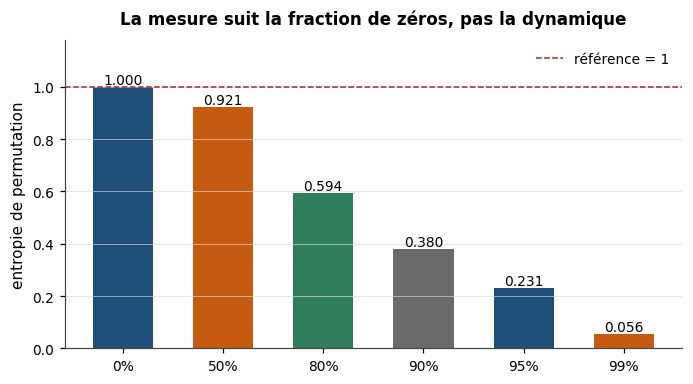

In [71]:
figures.barres_comparatives(
    resultats_zeros, ylabel="entropie de permutation",
    titre="La mesure suit la fraction de zéros, pas la dynamique", reference=1.0
);

**Même série, même information.** Un bruit de $10^{-9}$, sans aucune
signification physique, ramène la mesure au voisinage de 1.

**Conséquence pour le projet.** Une entropie de permutation calculée sur le
délestage quotidien mesurerait la fréquence des zéros plutôt que la dynamique
du réseau. Elle produirait une courbe nette en fonction du paramètre de
contrôle, entièrement explicable par un indicateur trivial — soit précisément
le mode d'échec que SO3 cherche à détecter, mais provenant de l'outil et non du
système.

**Décision.** Aucun bruit ajouté aux données, ce serait inventer de
l'information. L'analyse par entropie de permutation et SampEn portera sur la
distribution des taux de charge des lignes, disponible à chaque pas de temps et
dépourvue de zéros exacts. Le délestage et le nombre de lignes en panne restent
les observables du Hurst et des statistiques de taille de blackout.

L'exposant de Hurst n'est pas affecté de la même façon : R/S repose sur des
sommes cumulées et un écart-type, que les égalités ne perturbent pas. C'est
pourquoi Carreras a pu analyser ces séries sans rencontrer ce problème.

**Vérification systématique à faire** avant d'interpréter toute courbe
d'entropie : mesurer d'abord la fraction de valeurs identiques dans la série.

---
## 9. Le réseau en arbre

Premier module du fil A. La construction suit celle de Carreras : la racine
porte trois branches, chaque nœud du bord en reçoit deux à chaque génération,
et les générateurs sont placés au troisième niveau. Tous les nœuds internes ont
ainsi trois lignes incidentes, ce qui correspond approximativement à la moyenne
observée sur les grands réseaux réels.

In [72]:
for generations in range(3, 8):
    reseau = arbre(generations)
    print(f"{generations} générations : {reseau.n_noeuds:>3} nœuds, "
          f"{reseau.n_lignes:>3} lignes, {reseau.generateurs.size:>2} générateurs")

3 générations :  22 nœuds,  21 lignes, 12 générateurs
4 générations :  46 nœuds,  45 lignes, 12 générateurs
5 générations :  94 nœuds,  93 lignes, 12 générateurs
6 générations : 190 nœuds, 189 lignes, 12 générateurs
7 générations : 382 nœuds, 381 lignes, 12 générateurs


Ces tailles — 22, 46, 94, 190, 382 — sont exactement celles utilisées dans la
littérature de référence. Le réseau à 46 nœuds sert de cas de travail.

### L'approximation DC

Les flux se calculent en approximation DC : tensions supposées unitaires,
résistances négligées, différences d'angle petites. Le flux sur une ligne
devient proportionnel à la différence des angles de ses extrémités,

$$F_l = \frac{\theta_i - \theta_j}{x_l}$$

et les injections se relient aux angles par le laplacien pondéré du graphe,
$P = B\theta$. Un nœud de référence est exclu du système pour lever la
singularité : la somme des injections étant nulle, les angles ne sont définis
qu'à une constante près.

Le réseau reste parfaitement discret. C'est le modèle électrique qui est
simplifié, pas la géométrie.

degré moyen         : 1.96
lignes effectives   : 42.2 sur 45


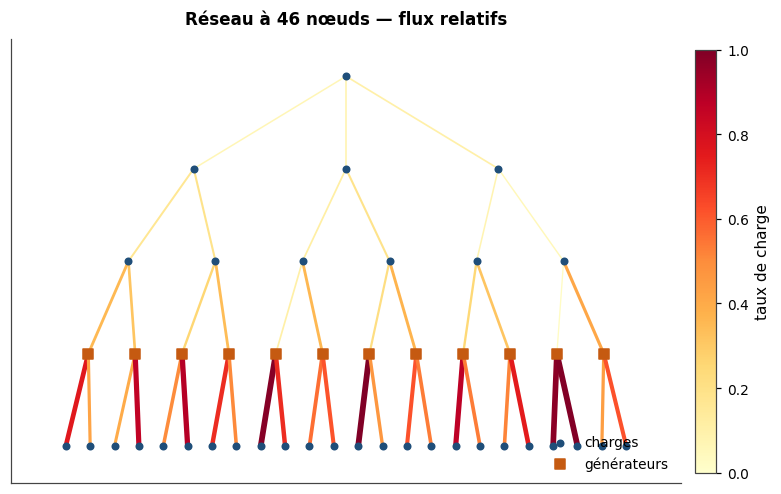

In [73]:
reseau = arbre(4)

demande = np.zeros(reseau.n_noeuds)
demande[reseau.charges] = -rng.uniform(0.5, 1.5, reseau.charges.size)
demande[reseau.generateurs] = -demande[reseau.charges].sum() / reseau.generateurs.size

A = matrice_de_flux(reseau)
f = flux(reseau, demande, A)
limites = limites_par_niveau(reseau)
taux = taux_de_charge(f, limites)

figures.reseau_en_arbre(reseau, taux=taux / taux.max(),
                        titre="Réseau à 46 nœuds — flux relatifs");

print(f"degré moyen         : {degres(reseau).mean():.2f}")
print(f"lignes effectives   : {nombre_effectif(f):.1f} sur {reseau.n_lignes}")

### La validation analytique

Dans un arbre, le chemin entre deux nœuds est unique. Retirer une ligne sépare
donc le réseau en deux, et toute la puissance échangée entre les deux parties
transite forcément par cette ligne. Le flux de chaque ligne doit donc égaler
exactement la puissance nette de son sous-arbre, **indépendamment des
réactances**.

C'est un résultat exact, vérifié sur les 45 lignes par la suite de tests. Le
calcul des flux est donc validé contre les mathématiques, et non contre une
autre implémentation — ce qui est la seule validation qui ait vraiment de la
valeur.

Le corollaire est vérifié aussi : changer les réactances d'un facteur 20 ne
modifie aucun flux sur un arbre. Rien à redistribuer quand il n'existe qu'un
seul chemin.

---
## Où en est le projet

**En place et validé** — les deux modules du fil B, `entropie` et
`indicateurs`, et les deux premiers du fil A, `reseau` et `dispatch`. 105
tests, environ vingt-cinq secondes. Résultats identiques entre Linux et
Windows.

**Deux constats méthodologiques** qui orientent la suite du projet. Le biais de
l'estimateur R/S impose de comparer à une distribution nulle plutôt qu'à la
valeur théorique. Et le traitement des égalités impose de choisir l'observable
avec soin plutôt que d'appliquer les mesures au délestage brut.

**Suite** — le carnet 02 couvre le dispatch et les deux transitions de charge.
Les modules `cascade` et `evolution` restent à écrire ; c'est ce dernier qui
produira les séries temporelles sur lesquelles tout ce qui précède sera
appliqué.